# GradCAM on MNIST

**Gradient-weighted Class Activation Mapping (GradCAM)** is a technique that produces a coarse localisation map highlighting the important regions in an image for predicting a concept.

Given a prediction, GradCAM asks: *which spatial locations in the last convolutional feature maps were most influential for this decision?*

**The key idea:**
1. Run a forward pass → get the class score.
2. Run a backward pass from that class score → get gradients w.r.t. the last conv feature maps.
3. Average the gradients spatially → one weight per feature map channel.
4. Take a weighted sum of the feature maps → a single spatial heatmap.
5. Apply ReLU (we only care about positive influence), normalise, and upsample.

**Paper:** Selvaraju et al., "Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization", ICCV 2017.  
https://arxiv.org/abs/1610.02391

---
### Notebook structure
| Section | Content |
|---|---|
| 1 | Imports & device |
| 2 | CNN architecture |
| 3 | MNIST data |
| 4 | Train / load weights |
| 5 | GradCAM — step by step |
| 6 | Visualise |
| 7 | Packaged function + experiments |

## 1. Imports & device

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

# Pick GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Network architecture

We need at least one convolutional layer for GradCAM to make sense. Here we use a small two-block CNN:

```
Input (1×28×28)
  └─ Conv1 (16 filters, 3×3, pad=1) → ReLU → MaxPool(2×2)   →  16×14×14
       └─ Conv2 (32 filters, 3×3, pad=1) → ReLU ← ── GradCAM hook here
                                         → MaxPool(2×2)  →  32×7×7
            └─ Flatten → FC(128) → ReLU → FC(10)
```

**GradCAM will be applied to `relu2`** — the ReLU *after* the last convolutional layer.

> **Why hook after ReLU, not on the conv layer itself?**  
> A conv layer output can contain large negative values. Weighting and summing those can produce an all-negative map, which ReLU then zeros out completely — giving a blank heatmap.  
> Hooking after ReLU gives activations that are ≥ 0, so the weighted sum retains meaningful signal.

In [57]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # --- Feature extractor ---
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 1×28×28 → 16×28×28
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)                          #           → 16×14×14

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) #           → 32×14×14
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)                          #           → 32×7×7

        # --- Classifier ---
        self.fc1   = nn.Linear(32 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)   # flatten
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x


model = SimpleCNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 206,922


## 3. MNIST data

In [58]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean & std
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Train samples: {len(train_dataset):,}')
print(f'Test  samples: {len(test_dataset):,}')

Train samples: 60,000
Test  samples: 10,000


## 4. Train the model  *(or load pretrained weights)*

Training takes **~2 minutes on a CPU** and ~30 s on a GPU. Run the training cell, or skip it and load the saved weights.

In [59]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


WEIGHT_PATH = Path('mnist_cnn.pth')

if WEIGHT_PATH.exists():
    # --- Load saved weights ---
    model.load_state_dict(torch.load(WEIGHT_PATH, map_location=device))
    print(f'Loaded weights from {WEIGHT_PATH}')
else:
    # --- Train from scratch ---
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    NUM_EPOCHS = 5
    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, test_loader, criterion, device)
        print(f'Epoch {epoch}/{NUM_EPOCHS}  '
              f'train loss {tr_loss:.4f}  acc {tr_acc:.4f}  |  '
              f'test  loss {va_loss:.4f}  acc {va_acc:.4f}')

    torch.save(model.state_dict(), WEIGHT_PATH)
    print(f'\nWeights saved to {WEIGHT_PATH}')

Epoch 1/5  train loss 0.1788  acc 0.9470  |  test  loss 0.0639  acc 0.9792
Epoch 2/5  train loss 0.0513  acc 0.9842  |  test  loss 0.0412  acc 0.9867
Epoch 3/5  train loss 0.0355  acc 0.9889  |  test  loss 0.0323  acc 0.9890
Epoch 4/5  train loss 0.0255  acc 0.9918  |  test  loss 0.0350  acc 0.9885
Epoch 5/5  train loss 0.0201  acc 0.9935  |  test  loss 0.0307  acc 0.9900

Weights saved to mnist_cnn.pth


In [60]:
# Quick sanity check on the test set
_, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
print(f'Test accuracy: {test_acc*100:.2f}%')

Test accuracy: 99.00%


---
## 5. GradCAM — step by step

We will work on a **single test image** throughout this section.

### Mathematical recap

Let $A^k \in \mathbb{R}^{H \times W}$ be the $k$-th feature map of the target layer, and $y^c$ be the score for class $c$ **before softmax**.

$$
\alpha_k^c = \underbrace{\frac{1}{HW}\sum_i\sum_j}_{\text{global avg pool}} \frac{\partial y^c}{\partial A^k_{ij}}
$$

$$
L^c_{\text{GradCAM}} = \text{ReLU}\!\left(\sum_k \alpha_k^c A^k\right)
$$

The ReLU keeps only the features that *increase* the target class score.

### 5.0  Pick a test image

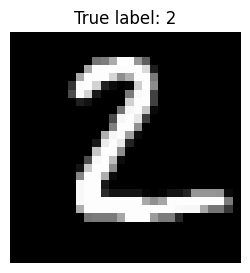

Input tensor shape: torch.Size([1, 1, 28, 28])


In [61]:
# Grab one image from the test set
IMAGE_INDEX = 1   # <-- change this to explore different images

image_tensor, true_label = test_dataset[IMAGE_INDEX]

# Add batch dimension and move to device
input_tensor = image_tensor.unsqueeze(0).to(device)  # shape: (1, 1, 28, 28)

# Show the image
plt.figure(figsize=(3, 3))
plt.imshow(image_tensor.squeeze(), cmap='gray')
plt.title(f'True label: {true_label}')
plt.axis('off')
plt.show()
print(f'Input tensor shape: {input_tensor.shape}')

### 5.1  Register forward & backward hooks

PyTorch **hooks** let us intercept the computation graph at any layer:
- A **forward hook** runs after the layer's `forward()` and captures its output (the feature maps $A^k$).
- A **backward hook** runs during `.backward()` and captures the gradients flowing through the layer.

In [62]:
# Storage containers
feature_maps = {}   # will hold A^k  (forward activations)
gradients    = {}   # will hold dY^c/dA^k  (backward gradients)

# ---- Hook functions ----
def forward_hook(module, input, output):
    """Captures the output of the target layer during the forward pass."""
    feature_maps['relu2'] = output          # shape: (1, 32, 14, 14)

def backward_hook(module, grad_input, grad_output):
    """Captures the gradient of the loss w.r.t. the target layer output during backward."""
    gradients['relu2'] = grad_output[0]     # shape: (1, 32, 14, 14)
    # Note: grad_output is a tuple; [0] is the gradient w.r.t. the layer output.

# ---- Attach hooks to relu2 (post-ReLU activations of the last conv block) ----
target_layer = model.relu2
h_fwd = target_layer.register_forward_hook(forward_hook)
h_bwd = target_layer.register_full_backward_hook(backward_hook)

print('Hooks registered on:', target_layer)

Hooks registered on: ReLU()


### 5.2  Forward pass

We run the image through the network. The forward hook fires and stores the feature maps.

In [63]:
model.eval()

# We need gradients during the forward pass (model.eval() disables dropout/BN
# but does NOT disable gradient computation — we still need it for GradCAM).
output = model(input_tensor)   # logits, shape: (1, 10)

predicted_class = output.argmax(dim=1).item()
print(f'True label     : {true_label}')
print(f'Predicted class: {predicted_class}')
print(f'Logits         : {output.detach().cpu().numpy().round(2)}')
print(f'\nFeature maps shape (A^k): {feature_maps["relu2"].shape}')  # (1, 32, 14, 14)
# Note: 14×14 because relu2 comes before pool2 — the spatial downsampling hasn't happened yet.

True label     : 2
Predicted class: 2
Logits         : [[  2.63   5.4   19.29 -17.31  -5.93 -14.73  -1.35 -12.63  -5.52  -8.34]]

Feature maps shape (A^k): torch.Size([1, 32, 14, 14])


### 5.3  Backward pass for the target class

We choose a target class $c$ (here: the predicted class) and compute
$$\frac{\partial y^c}{\partial A^k_{ij}}$$
for all $k, i, j$ by back-propagating a one-hot gradient through the network.

In [64]:
TARGET_CLASS = predicted_class   # try changing this to a different digit!

# Build a one-hot gradient vector: gradient only flows through the target class score
one_hot = torch.zeros_like(output)          # shape: (1, 10)
one_hot[0, TARGET_CLASS] = 1.0

model.zero_grad()
output.backward(gradient=one_hot)           # backward hook fires here

print(f'Targeting class : {TARGET_CLASS}')
print(f'Gradients shape : {gradients["relu2"].shape}')   # (1, 32, 14, 14)

Targeting class : 2
Gradients shape : torch.Size([1, 32, 14, 14])


### 5.4  Compute gradient weights $\alpha_k^c$

We **globally average-pool** the gradients over the spatial dimensions $(H, W)$:

$$\alpha_k^c = \frac{1}{H \cdot W}\sum_{i=1}^{H}\sum_{j=1}^{W} \frac{\partial y^c}{\partial A^k_{ij}}$$

This gives one scalar weight per channel — how important is channel $k$ for class $c$?

In [65]:
grads = gradients['relu2']               # (1, 32, 14, 14)

# Global average pooling over (H, W) = (14, 14)
alpha = grads.mean(dim=[2, 3])           # (1, 32) — one weight per channel

print(f'Gradient weights shape: {alpha.shape}')   # torch.Size([1, 32])
print(f'First 8 weights: {alpha[0, :8].detach().cpu().numpy().round(4)}')

Gradient weights shape: torch.Size([1, 32])
First 8 weights: [-0.0002 -0.0013  0.0046  0.0024  0.0002 -0.0011  0.0005  0.0016]


### 5.5  Weighted combination of feature maps

We compute a weighted sum of all 32 feature maps:
$$\text{cam} = \sum_{k=1}^{32} \alpha_k^c \cdot A^k$$

This produces a single **14×14 map** that highlights which spatial regions drove the prediction.

> Because we hooked on `relu2` (post-ReLU, pre-pool), the feature maps are non-negative.  
> That means positive $\alpha_k$ channels add brightness, and negative $\alpha_k$ channels *suppress* it.  
> The final ReLU in step 5.6 then keeps only the net-positive regions.

CAM shape (before ReLU): torch.Size([1, 14, 14])
Value range            : [-0.005, 0.049]


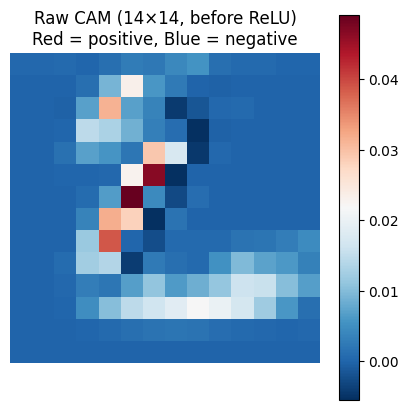

In [76]:
fmaps = feature_maps['relu2']            # (1, 32, 14, 14)

# Reshape alpha for broadcasting: (1, 32) → (1, 32, 1, 1)
alpha_reshaped = alpha.unsqueeze(-1).unsqueeze(-1)  # (1, 32, 1, 1)

# Weighted sum across channel dimension → (1, 14, 14)
cam = (alpha_reshaped * fmaps).sum(dim=1)           # (1, 14, 14)

print(f'CAM shape (before ReLU): {cam.shape}')      # torch.Size([1, 14, 14])
print(f'Value range            : [{cam.min():.3f}, {cam.max():.3f}]')

plt.figure(figsize=(5, 5))
plt.imshow(cam.detach().cpu().squeeze(), cmap='RdBu_r')
plt.title('Raw CAM (14×14, before ReLU)\nRed = positive, Blue = negative')
plt.colorbar()
plt.axis('off')
plt.show()

### 5.6  Apply ReLU and normalise

We apply **ReLU** to keep only the regions that *positively* influence the target class score (negative values would mean the region actively suppresses the class).

Then we normalise to $[0, 1]$ for visualisation.

CAM value range after normalisation: [0.000, 1.000]


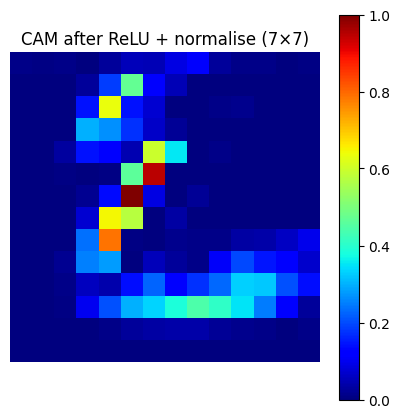

In [77]:
cam = F.relu(cam)                        # keep only positive influence

# Normalise to [0, 1]
cam_min = cam.min()
cam_max = cam.max()
cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

print(f'CAM value range after normalisation: [{cam.min():.3f}, {cam.max():.3f}]')

plt.figure(figsize=(5, 5))
plt.imshow(cam.detach().cpu().squeeze(), cmap='jet', vmin=0, vmax=1)
plt.title('CAM after ReLU + normalise (7×7)')
plt.colorbar()
plt.axis('off')
plt.show()

### 5.7  Upsample to input resolution (28×28)

The CAM is 14×14 (the spatial resolution of `relu2`, before `pool2`). We bilinearly upsample it to match the 28×28 input image.

Upsampled CAM shape: (28, 28)


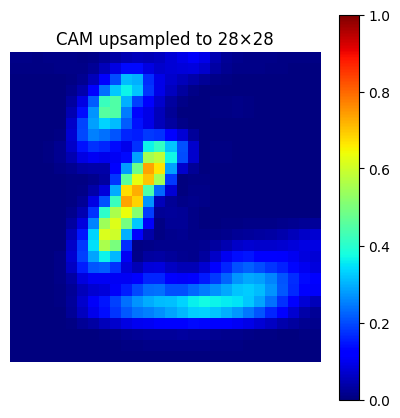

In [78]:
# interpolate expects (N, C, H, W); cam is (1, 14, 14) → add channel dim → (1, 1, 14, 14)
cam_4d = cam.unsqueeze(0)               # (1, 1, 14, 14)

cam_upsampled = F.interpolate(
    cam_4d,
    size=(28, 28),
    mode='bilinear',
    align_corners=False
)                                        # (1, 1, 28, 28)

cam_np = cam_upsampled.squeeze().detach().cpu().numpy()   # (28, 28)

print(f'Upsampled CAM shape: {cam_np.shape}')   # (28, 28)

plt.figure(figsize=(5, 5))
plt.imshow(cam_np, cmap='jet', vmin=0, vmax=1)
plt.title('CAM upsampled to 28×28')
plt.colorbar()
plt.axis('off')
plt.show()

---
## 6. Visualise the GradCAM heatmap

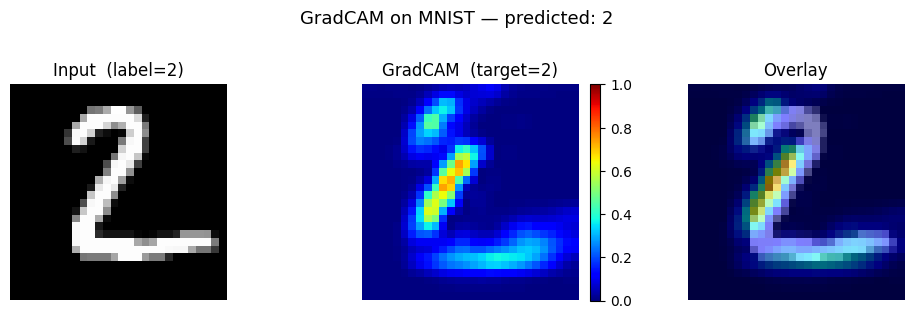

In [69]:
# Convert the normalised input image to numpy for display
img_np = image_tensor.squeeze().numpy()   # (28, 28), values roughly in [-2.8, 2.8]

# Rescale image to [0, 1] for display
img_display = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

# Build an RGBA heatmap using the 'jet' colormap
heatmap_rgba = cm.jet(cam_np)             # (28, 28, 4)  values in [0, 1]
heatmap_rgb  = heatmap_rgba[:, :, :3]    # drop alpha → (28, 28, 3)

# Convert grayscale image to RGB so we can overlay
img_rgb = np.stack([img_display] * 3, axis=-1)   # (28, 28, 3)

# Alpha-blend: overlay = alpha * heatmap + (1 - alpha) * image
ALPHA = 0.5
overlay = ALPHA * heatmap_rgb + (1 - ALPHA) * img_rgb
overlay = np.clip(overlay, 0, 1)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(img_display, cmap='gray')
axes[0].set_title(f'Input  (label={true_label})')

im = axes[1].imshow(cam_np, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f'GradCAM  (target={TARGET_CLASS})')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(overlay)
axes[2].set_title('Overlay')

for ax in axes:
    ax.axis('off')

plt.suptitle(f'GradCAM on MNIST — predicted: {predicted_class}', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Don't forget to remove the hooks!
h_fwd.remove()
h_bwd.remove()

---
## 7. Packaged GradCAM function

Now that we understand every step, let's wrap everything into a reusable function.

In [70]:
def gradcam(model, input_tensor, target_layer, target_class=None):
    """
    Compute GradCAM for a single image.

    Parameters
    ----------
    model        : nn.Module  — trained model (in eval mode)
    input_tensor : Tensor     — shape (1, C, H, W), on the same device as model
    target_layer : nn.Module  — the convolutional layer to explain
    target_class : int|None   — class to explain; None → use predicted class

    Returns
    -------
    cam_np       : np.ndarray — normalised heatmap, shape (H, W), values in [0, 1]
    pred_class   : int        — the predicted class index
    """
    _feature_maps = {}
    _gradients    = {}

    def _fwd_hook(module, inp, out):
        _feature_maps['x'] = out

    def _bwd_hook(module, grad_in, grad_out):
        _gradients['x'] = grad_out[0]

    h_fwd = target_layer.register_forward_hook(_fwd_hook)
    h_bwd = target_layer.register_full_backward_hook(_bwd_hook)

    try:
        model.eval()

        # Forward
        output = model(input_tensor)              # (1, num_classes)
        pred_class = output.argmax(dim=1).item()
        if target_class is None:
            target_class = pred_class

        # Backward
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        model.zero_grad()
        output.backward(gradient=one_hot)

        # Weights: global average pool of gradients  →  (1, C)
        grads  = _gradients['x']                  # (1, C, h, w)
        alpha  = grads.mean(dim=[2, 3])            # (1, C)

        # Weighted sum of feature maps  →  (1, h, w)
        fmaps  = _feature_maps['x']               # (1, C, h, w)
        cam    = (alpha.unsqueeze(-1).unsqueeze(-1) * fmaps).sum(dim=1)  # (1, h, w)

        # ReLU + normalise
        cam    = F.relu(cam)
        cam    = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Upsample to input H×W
        H, W   = input_tensor.shape[-2:]
        cam    = F.interpolate(cam.unsqueeze(0), size=(H, W),
                               mode='bilinear', align_corners=False)
        cam_np = cam.squeeze().detach().cpu().numpy()    # (H, W)

    finally:
        h_fwd.remove()
        h_bwd.remove()

    return cam_np, pred_class


print('gradcam() function defined.')

gradcam() function defined.


### 7.1  Explore multiple test images

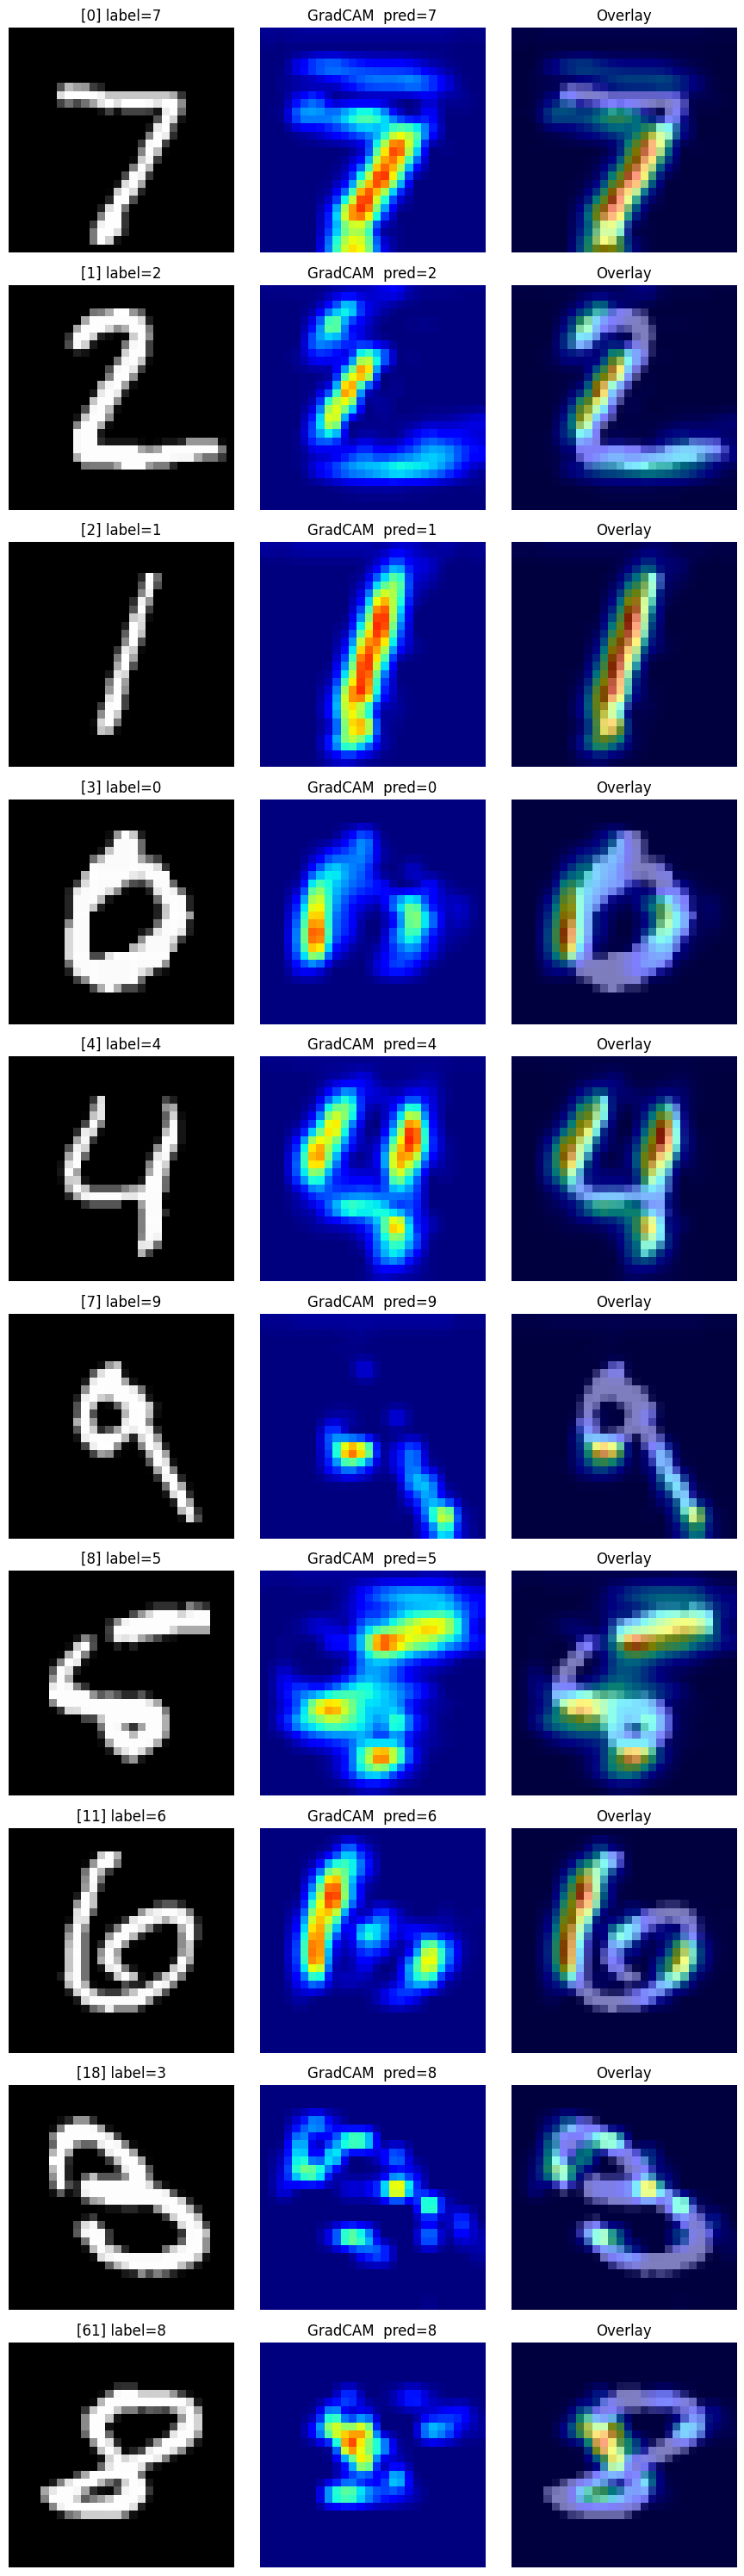

In [71]:
def show_gradcam(model, dataset, indices, target_layer, target_class=None):
    """Display GradCAM for a list of image indices from a dataset."""
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]
        inp = img_tensor.unsqueeze(0).to(device)

        cam_np, pred = gradcam(model, inp, target_layer, target_class)

        img_np = img_tensor.squeeze().numpy()
        img_display = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        heatmap_rgb = cm.jet(cam_np)[:, :, :3]
        img_rgb     = np.stack([img_display] * 3, axis=-1)
        overlay     = np.clip(0.5 * heatmap_rgb + 0.5 * img_rgb, 0, 1)

        axes[row, 0].imshow(img_display, cmap='gray')
        axes[row, 0].set_title(f'[{idx}] label={true_label}')

        im = axes[row, 1].imshow(cam_np, cmap='jet', vmin=0, vmax=1)
        axes[row, 1].set_title(f'GradCAM  pred={pred}')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Overlay')

        for ax in axes[row]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# Show GradCAM for one example of each digit
# Find the first occurrence of each digit in the test set
one_per_class = []
seen = set()
for i, (_, lbl) in enumerate(test_dataset):
    if lbl not in seen:
        one_per_class.append(i)
        seen.add(lbl)
    if len(seen) == 10:
        break

# Hook on relu2 — post-ReLU activations of the last conv block
show_gradcam(model, test_dataset, one_per_class, model.relu2)

### 7.2  Counter-factual GradCAM

What does the network look at when it considers a **wrong** class for a digit?

True label: 6


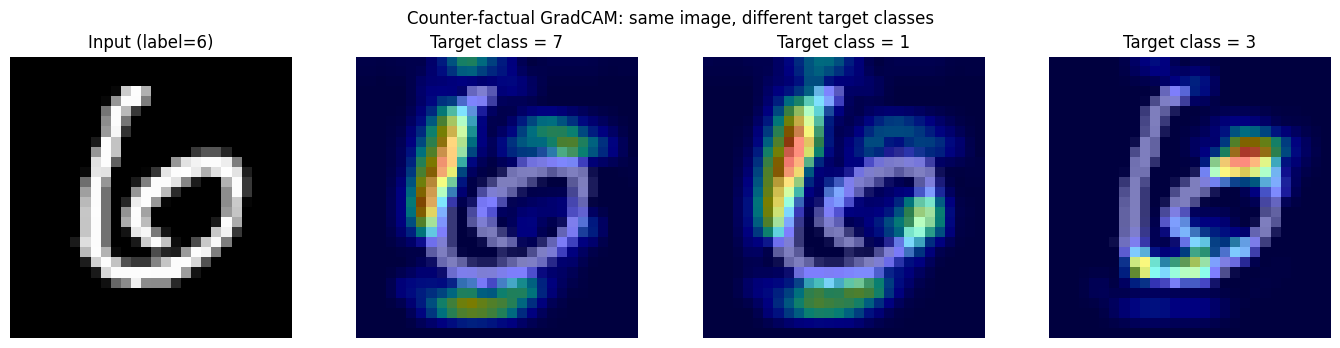

In [73]:
# Pick a '7' and ask GradCAM to explain class '1' vs the true class '7'
idx_seven = one_per_class[7]   # index in test_dataset whose label is 7

img_tensor, true_label = test_dataset[idx_seven]
print(f'True label: {true_label}')

inp = img_tensor.unsqueeze(0).to(device)
img_np      = img_tensor.squeeze().numpy()
img_display = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(img_display, cmap='gray')
axes[0].set_title(f'Input (label={true_label})')

for col, tc in enumerate([7, 1, 3], start=1):
    cam_np, pred = gradcam(model, inp, model.relu2, target_class=tc)
    heatmap_rgb  = cm.jet(cam_np)[:, :, :3]
    img_rgb      = np.stack([img_display] * 3, axis=-1)
    overlay      = np.clip(0.5 * heatmap_rgb + 0.5 * img_rgb, 0, 1)
    axes[col].imshow(overlay)
    axes[col].set_title(f'Target class = {tc}')

for ax in axes:
    ax.axis('off')

plt.suptitle('Counter-factual GradCAM: same image, different target classes', fontsize=12)
plt.tight_layout()
plt.show()

---
## Discussion questions

1. **Spatial resolution:** GradCAM produces a 14×14 map for a 28×28 input (we hook on `relu2`, which is before `pool2`). How would the map change if you hooked *after* `pool2` instead? What is the general trade-off between network depth and localisation precision?

2. **ReLU:** We apply ReLU to the weighted CAM. What would happen if you removed it? Try commenting out `cam = F.relu(cam)` and compare the visualisations.

3. **Choice of layer:** We applied GradCAM to `relu2`. What happens if you use `model.relu1` instead? (The spatial resolution will be 28×28 — no upsampling needed.)

4. **Counter-factual:** When targeting a wrong class (e.g., asking for class `1` on a `7`), which regions light up? Does it make intuitive sense?

5. **Failure cases:** Find an image the network **mis-classifies**. Does the GradCAM heatmap suggest *why* the model was confused?